# Data Experience — Fase 1: Selección, exploración y preparación de datos

**Dataset:** Google Play Store Apps (Kaggle)

**Justificación:** Como estudiantes de Ingeniería de Sistemas, entender cómo se distribuye y evalúa el software en una de las plataformas más grandes del mundo (Google Play Store) nos acerca a problemas reales del área: calidad de datos en catálogos de aplicaciones, versiones de sistema operativo soportadas, modelos de monetización (apps gratis/pagas) y comportamiento de los usuarios (instalaciones, calificaciones, reseñas). Es un dataset real, público y directamente relacionado con el ciclo de vida del software.

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('googleplaystore.csv')
print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 2. Exploración inicial

Identificamos tipos de variable, valores nulos, duplicados y distribuciones.

In [2]:
# Tipos de dato por columna
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [3]:
# Valores nulos por columna
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [4]:
# Duplicados
print('Filas duplicadas exactas:', df.duplicated().sum())
print('Apps con nombre repetido:', df.duplicated(subset=['App']).sum())

Filas duplicadas exactas: 483
Apps con nombre repetido: 1181


In [5]:
# Distribucion inicial de variables numericas
df.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Buscamos valores 'raros' en columnas que deberian ser numericas pero llegan como texto
print('Category tiene un valor invalido (fila corrupta):')
print(df[df['Category'] == '1.9'])
print()
print('Valores unicos de Type:', df['Type'].unique())
print('Ejemplos de Size:', df['Size'].unique()[:10])
print('Ejemplos de Installs:', df['Installs'].unique()[:10])
print('Ejemplos de Price:', df['Price'].unique()[:10])

Category tiene un valor invalido (fila corrupta):
                                           App Category  Rating Reviews  \
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9    19.0    3.0M   

         Size Installs Type     Price Content Rating             Genres  \
10472  1,000+     Free    0  Everyone            NaN  February 11, 2018   

      Last Updated Current Ver Android Ver  
10472       1.0.19  4.0 and up         NaN  

Valores unicos de Type: ['Free' 'Paid' nan '0']
Ejemplos de Size: ['19M' '14M' '8.7M' '25M' '2.8M' '5.6M' '29M' '33M' '3.1M' '28M']
Ejemplos de Installs: ['10,000+' '500,000+' '5,000,000+' '50,000,000+' '100,000+' '50,000+'
 '1,000,000+' '10,000,000+' '5,000+' '100,000,000+']
Ejemplos de Price: ['0' '$4.99' '$3.99' '$6.99' '$1.49' '$2.99' '$7.99' '$5.99' '$3.49'
 '$1.99']


### Problemas detectados

1. **Fila corrupta (indice 10472):** a la fila le falta el valor de `Category`, entonces todas las columnas siguientes quedaron corridas una posicion. Esto se nota porque `Category` tiene el valor `'1.9'`, que en realidad es un `Rating`.
2. **Nulos:** `Rating` tiene ~1,474 valores nulos (apps sin suficientes calificaciones); tambien hay nulos sueltos en `Type`, `Content Rating`, `Current Ver` y `Android Ver`.
3. **Duplicados:** 483 filas exactamente duplicadas y 1,181 apps con el nombre repetido (la misma app aparece varias veces, probablemente scrapeada en distintos momentos).
4. **Columnas numericas guardadas como texto:**
   - `Installs`: formato `"10,000+"` (coma y simbolo `+`).
   - `Price`: formato `"$4.99"` (simbolo de dolar).
   - `Size`: mezcla `"19M"`, `"14k"` y el texto `"Varies with device"`.
   - `Reviews`: numero como texto.
5. **Fechas como texto:** `Last Updated` viene en formato `"January 7, 2018"` en vez de tipo fecha.

## 3. Limpieza y transformacion

In [7]:
df_clean = df.copy()

# 3.1 Eliminar la fila corrupta (columnas corridas)
df_clean = df_clean.drop(index=10472)

# 3.2 Eliminar duplicados exactos
df_clean = df_clean.drop_duplicates()

print('Filas despues de quitar la fila corrupta y duplicados exactos:', df_clean.shape)

Filas despues de quitar la fila corrupta y duplicados exactos: (10357, 13)


In [8]:
# 3.3 Convertir Reviews a numero y quedarnos con la version mas reciente/confiable de cada app
# (misma app repetida -> nos quedamos con la fila que tiene mas Reviews)
df_clean['Reviews'] = df_clean['Reviews'].astype(int)
df_clean = df_clean.sort_values('Reviews', ascending=False).drop_duplicates(subset='App', keep='first')

print('Filas despues de quitar apps repetidas:', df_clean.shape)

Filas despues de quitar apps repetidas: (9659, 13)


In [9]:
# 3.4 Limpiar Installs: quitar comas y el simbolo '+', convertir a entero
df_clean['Installs'] = df_clean['Installs'].str.replace('[+,]', '', regex=True).astype(int)

# 3.5 Limpiar Price: quitar el simbolo '$', convertir a decimal
df_clean['Price'] = df_clean['Price'].str.replace('$', '', regex=False).astype(float)

# 3.6 Limpiar Size: pasar todo a megabytes (numero); 'Varies with device' queda como nulo
def limpiar_size(valor):
    if 'M' in valor:
        return float(valor.replace('M', ''))
    elif 'k' in valor:
        return float(valor.replace('k', '')) / 1024
    else:
        return np.nan

df_clean['Size'] = df_clean['Size'].apply(limpiar_size)

# 3.7 Convertir Last Updated a fecha real
df_clean['Last Updated'] = pd.to_datetime(df_clean['Last Updated'])

df_clean[['App', 'Installs', 'Price', 'Size', 'Last Updated']].head()

,App,Installs,Price,Size,Last Updated
2544,Facebook,1000000000,0.0,NaN,2018-08-03
336,WhatsApp Messenger,1000000000,0.0,NaN,2018-08-03
2604,Instagram,1000000000,0.0,NaN,2018-07-31
382,Messenger – Text and Video Chat for Free,1000000000,0.0,NaN,2018-08-01
1879,Clash of Clans,100000000,0.0,98.0,2018-07-15


**Nota sobre `Rating`:** decidimos **no inventar** un valor para los 1,463 nulos restantes (ej. no rellenamos con el promedio), porque un rating nulo representa una app real sin suficientes calificaciones todavia — inventar un numero distorsionaria el analisis. Se documenta como limitacion del dataset.

In [10]:
# 3.8 Nulos sueltos en columnas categoricas: se marcan explicitamente como 'Desconocido'
for col in ['Type', 'Content Rating', 'Current Ver', 'Android Ver']:
    df_clean[col] = df_clean[col].fillna('Desconocido')

print('Nulos finales por columna:')
df_clean.isnull().sum()

Nulos finales por columna:


App                  0
Category             0
Rating            1463
Reviews              0
Size              1228
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64

## 4. Tabla resumen del dataset depurado

In [11]:
print('Dataset original:', df.shape)
print('Dataset depurado:', df_clean.shape)
print()
df_clean.info()

Dataset original: (10841, 13)
Dataset depurado: (9659, 13)

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 2544 to 6329
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          8196 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            8431 non-null   float64       
 5   Installs        9659 non-null   int64         
 6   Type            9659 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9659 non-null   object        
 12  Android Ver     9659 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object

In [12]:
resumen = pd.DataFrame({
    'columna': df_clean.columns,
    'tipo_dato': df_clean.dtypes.values,
    'nulos': df_clean.isnull().sum().values,
    'valores_unicos': [df_clean[c].nunique() for c in df_clean.columns]
})
resumen

,columna,tipo_dato,nulos,valores_unicos
0,App,object,0,9659
1,Category,object,0,33
2,Rating,float64,1463,39
3,Reviews,int64,0,5334
4,Size,float64,1228,459
5,Installs,int64,0,20
6,Type,object,0,3
7,Price,float64,0,92
8,Content Rating,object,0,6
9,Genres,object,0,118


In [13]:
# Guardar el dataset ya depurado para usarlo en las siguientes fases del proyecto
df_clean.to_csv('googleplaystore_clean.csv', index=False)
print('Archivo guardado: googleplaystore_clean.csv')

Archivo guardado: googleplaystore_clean.csv


## Modulo 2: Analisis Estadistico

Partimos del dataset ya depurado (`df_clean`) para calcular medidas descriptivas sobre las variables numericas mas relevantes: `Rating`, `Reviews`, `Installs`, `Size` y `Price`.

**Nota sobre confiabilidad de los datos:** antes de interpretar cualquier estadistica hay que tener en cuenta que `Installs` viene en Google Play como un rango redondeado (ej. "100,000+"), no como un conteo exacto. Esto significa que los calculos con esta variable (media, varianza, etc.) son aproximaciones utiles para comparar apps entre si, pero no representan el numero real de instalaciones. `Reviews` si es un conteo exacto reportado por la plataforma, por lo que es una variable mas confiable para medir popularidad real.

### 1. Medidas de tendencia central (media, mediana, moda)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Rating', 'Reviews', 'Installs', 'Size']

tendencia_central = pd.DataFrame({
    'media': [df_clean[v].mean() for v in variables],
    'mediana': [df_clean[v].median() for v in variables],
    'moda': [df_clean[v].mode().iloc[0] for v in variables]
}, index=variables)

tendencia_central

,media,mediana,moda
Rating,4.173267e+00,4.3,4.3
Reviews,2.168041e+05,969.0,0.0
Installs,7.798170e+06,100000.0,1000000.0
Size,2.039807e+01,12.0,11.0


**Interpretacion:**
- **Rating:** media 4.17, mediana 4.3, moda 4.3. Las tres estan cerca -> las calificaciones se concentran en el rango "buena app" (4.0-4.5), sin distorsion fuerte de valores extremos.
- **Reviews:** media 216,804 pero mediana solo 969. Una diferencia enorme: significa que **pocas apps muy populares (Facebook, WhatsApp, Instagram) inflan el promedio**, mientras que la app "tipica" del catalogo tiene menos de 1,000 reseñas. La moda es 0 (muchisimas apps nuevas sin ninguna reseña todavia).
- **Installs:** mismo patron - media de ~7.8 millones vs mediana de solo 100,000. Confirma que **la mayoria de apps en la tienda tienen pocas instalaciones**, y un grupo pequeño de apps gigantes distorsiona el promedio general.
- **Size:** media 20.4 MB, mediana 12 MB -> tambien hay algunas apps muy pesadas que suben el promedio, pero la mayoria de apps son livianas.

### 2. Medidas de dispersion (rango, varianza, desviacion estandar)

In [15]:
dispersion = pd.DataFrame({
    'rango': [df_clean[v].max() - df_clean[v].min() for v in variables],
    'varianza': [df_clean[v].var() for v in variables],
    'desv_estandar': [df_clean[v].std() for v in variables]
}, index=variables)

dispersion

,rango,varianza,desv_estandar
Rating,4.000000e+00,2.875672e-01,5.362529e-01
Reviews,7.815831e+07,3.354137e+12,1.831430e+06
Installs,1.000000e+09,2.891184e+15,5.376973e+07
Size,9.999170e+01,4.765034e+02,2.182896e+01


**Interpretacion:**
- **Rating** tiene desviacion estandar muy baja (0.54) sobre un rango de solo 4 puntos -> es una variable **estable y poco dispersa**, casi todas las apps califican parecido.
- **Reviews** e **Installs** tienen una dispersion gigantesca (desviaciones estandar de millones), mucho mayor que su propia media. Esto es la señal estadistica de un **mercado muy desigual**: unas pocas apps concentran casi todas las instalaciones y reseñas, y la mayoria vive en un nicho pequeño. En terminos de negocio de software, esto refleja el fenomeno de "the winner takes most" en tiendas de aplicaciones.
- **Size** tiene dispersion moderada (desv. estandar ~22 MB): hay variedad de tamaños pero sin tanto extremo como Reviews/Installs.

### 3. Comparacion entre variables (Free vs Paid, y por categoria)

In [16]:
comparacion_tipo = df_clean.groupby('Type')[['Rating', 'Installs']].mean()
comparacion_tipo

,Rating,Installs
Type,,
Desconocido,NaN,0.000000e+00
Free,4.166223,8.452961e+06
Paid,4.262126,7.607929e+04


**Interpretacion:** las apps **pagas tienen un rating promedio levemente mayor** (4.26 vs 4.17 en gratis), pero **muchisimas menos instalaciones** (~76 mil vs ~8.4 millones en promedio). Tiene sentido desde la perspectiva de producto: quien paga por una app generalmente ya sabe lo que quiere y la valora mejor, pero la barrera de pago reduce fuertemente el volumen de descargas.

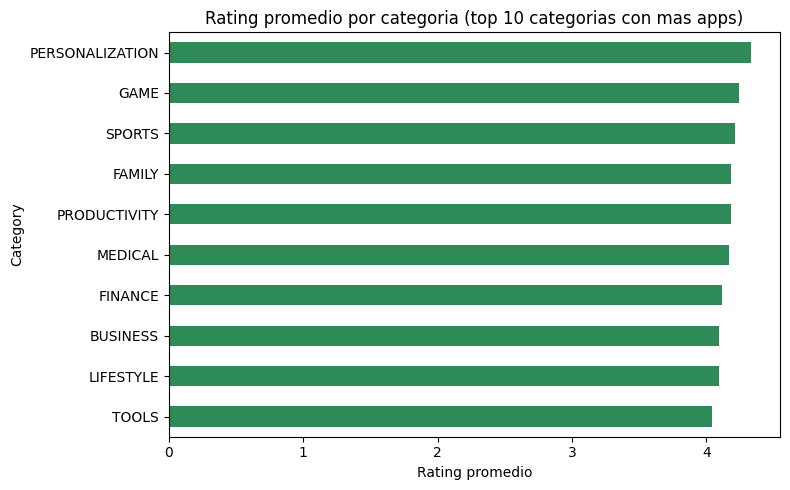

In [17]:
top_categorias = df_clean['Category'].value_counts().head(10).index
rating_por_categoria = df_clean[df_clean['Category'].isin(top_categorias)].groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
rating_por_categoria.plot(kind='barh', color='seagreen')
plt.xlabel('Rating promedio')
plt.title('Rating promedio por categoria (top 10 categorias con mas apps)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretacion:** entre las categorias con mas apps, **PERSONALIZATION** y **GAME** tienen el rating promedio mas alto (>4.2), mientras que **TOOLS** tiene el mas bajo (~4.0). Esto sugiere que apps de utilidad/herramientas son mas dificiles de calificar bien (suelen tener bugs, permisos invasivos o comparacion directa con alternativas del sistema), mientras que apps de entretenimiento/personalizacion generan mas satisfaccion.

### 4. Outliers, relaciones e hipotesis

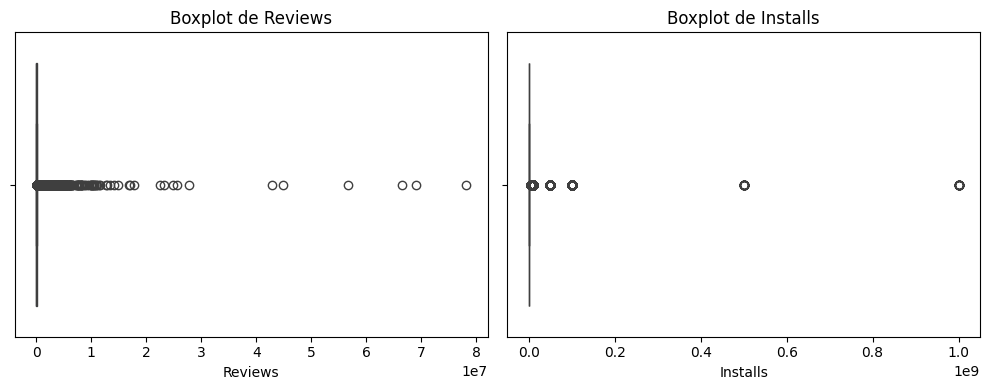

In [18]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df_clean['Reviews'])
plt.title('Boxplot de Reviews')

plt.subplot(1,2,2)
sns.boxplot(x=df_clean['Installs'])
plt.title('Boxplot de Installs')

plt.tight_layout()
plt.show()

In [19]:
def contar_outliers(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + 1.5 * IQR
    return (serie > limite_sup).sum(), limite_sup

for col in ['Reviews', 'Installs']:
    n_outliers, limite = contar_outliers(df_clean[col])
    print(f'{col}: {n_outliers} outliers de {len(df_clean)} filas (limite superior IQR = {limite:,.0f})')

Reviews: 1659 outliers de 9659 filas (limite superior IQR = 73,596)
Installs: 1981 outliers de 9659 filas (limite superior IQR = 2,498,500)


**Interpretacion:** con el metodo del rango intercuartilico (IQR), alrededor de **1,659 apps son outliers en Reviews** y **1,981 en Installs** (aprox. 17-20% del dataset). No los eliminamos porque **no son errores de captura, son apps reales extremadamente populares** (Facebook, WhatsApp, Instagram, juegos masivos). Aqui el outlier es informacion valiosa, no ruido a limpiar.

In [20]:
apps_caras = df_clean[df_clean['Price'] > 50][['App','Category','Price']].sort_values('Price', ascending=False)
apps_caras.head(10)

,App,Category,Price
4367,I'm Rich - Trump Edition,LIFESTYLE,400.00
5351,I am rich,LIFESTYLE,399.99
5369,I am Rich,FINANCE,399.99
9934,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,399.99
4197,most expensive app (H),FAMILY,399.99
5373,I AM RICH PRO PLUS,FINANCE,399.99
5356,I Am Rich Premium,FINANCE,399.99
5364,I am rich (Most expensive app),FINANCE,399.99
5358,I am Rich!,FINANCE,399.99
5362,I Am Rich Pro,FAMILY,399.99


**Interpretacion:** aparecen apps como *"I Am Rich"* / *"I'm Rich - Trump Edition"* con precio de **$399.99-$400**. Estas no son apps con funcionalidad real: son "apps broma" que solo demuestran que el usuario puede pagar mucho dinero. Son outliers legitimos de precio, y confirman que **el precio de una app no siempre refleja su complejidad o utilidad real** — un dato importante a considerar si se quisiera usar `Price` como variable en un modelo predictivo mas adelante.

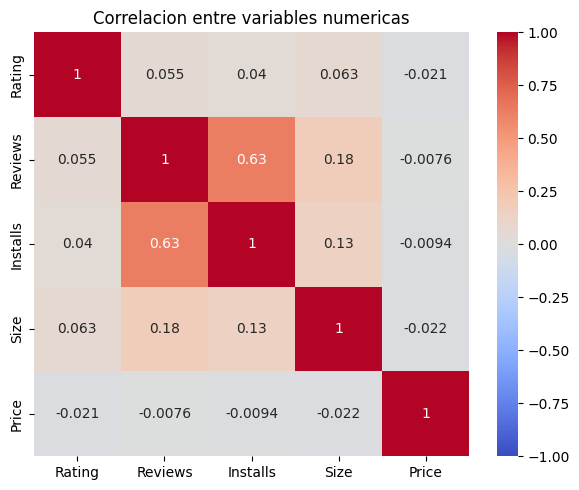

In [21]:
plt.figure(figsize=(6,5))
sns.heatmap(df_clean[['Rating','Reviews','Installs','Size','Price']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlacion entre variables numericas')
plt.tight_layout()
plt.show()

**Interpretacion de correlaciones:**
- **Reviews e Installs tienen correlacion fuerte (0.63):** tiene sentido, mas gente instala una app -> mas gente puede dejar reseña. Es la relacion mas solida del dataset.
- **Rating casi no se correlaciona con nada** (valores cercanos a 0 con Reviews, Installs, Size y Price). Esto sugiere que **la calidad percibida (rating) es independiente de que tan popular, pesada o costosa sea una app** — una app pequeña y gratis puede calificar tan bien como una app grande y paga.
- **Price no se correlaciona con ninguna otra variable**, lo cual refuerza el hallazgo anterior de las apps "broma": el precio en este dataset no sigue una logica de valor real.

**Hipotesis para profundizar en un modulo posterior:**
1. *Instalaciones impulsan reseñas, no al reves*: seria interesante cruzar con fechas para ver si el crecimiento de Reviews sigue al de Installs en el tiempo.
2. *El rating depende mas de la categoria que del tamaño o precio de la app* (dado que categorias como PERSONALIZATION rankean mas alto de forma consistente).
3. *Las apps pagas retienen mejor a su publico* (mayor rating con muchas menos instalaciones) podria explorarse comparando tasas de desinstalacion si se consiguiera esa variable.

### 5. Estrategias de manejo de outliers

No existe una unica forma correcta de tratar un outlier; depende de si el valor es un **error** o un **dato real**. Aplicamos criterio distinto para cada caso encontrado en este dataset:

| Outlier detectado | Es un error o es real? | Estrategia elegida | Por que |
|---|---|---|---|
| Facebook, WhatsApp, Instagram (Installs/Reviews extremos) | **Real** | **Conservacion** + transformacion logaritmica solo para graficar/comparar | Son apps reales; borrarlas ocultaria informacion clave del mercado |
| Apps "I Am Rich" a $400 (Price) | **Real** (apps broma, pero existen y se vendieron asi) | **Conservacion**, documentando el caso | El precio absurdo es intencional del desarrollador, no un error de captura |
| (Hipotetico) una fila con `Rating = 200` | **Error** | **Eliminacion o capping** | Un rating fuera del rango 1-5 no puede ser real en Google Play |

Como en nuestro dataset **no encontramos errores de captura reales** (los outliers de Installs, Reviews y Price son datos genuinos), no eliminamos ni imputamos ninguna fila por ser outlier. En su lugar, aplicamos **transformacion logaritmica** para poder visualizar y comparar estas variables sin que los valores extremos opaquen el resto, y dejamos tambien un ejemplo de **capping (recorte por percentiles)** como tecnica alternativa, por si se necesitara para un modelo sensible a outliers mas adelante.

**5.1 Transformacion logaritmica** (reduce el impacto de los extremos sin eliminarlos)

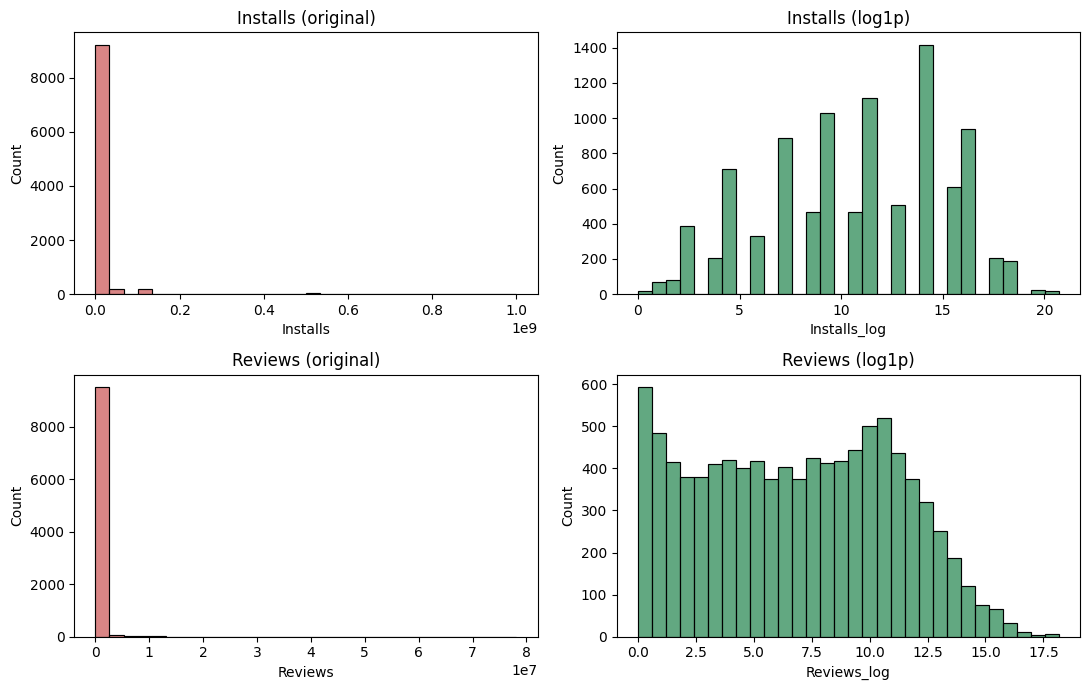

In [22]:
df_clean['Installs_log'] = np.log1p(df_clean['Installs'])
df_clean['Reviews_log'] = np.log1p(df_clean['Reviews'])

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

sns.histplot(df_clean['Installs'], bins=30, ax=axes[0,0], color='indianred')
axes[0,0].set_title('Installs (original)')

sns.histplot(df_clean['Installs_log'], bins=30, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Installs (log1p)')

sns.histplot(df_clean['Reviews'], bins=30, ax=axes[1,0], color='indianred')
axes[1,0].set_title('Reviews (original)')

sns.histplot(df_clean['Reviews_log'], bins=30, ax=axes[1,1], color='seagreen')
axes[1,1].set_title('Reviews (log1p)')

plt.tight_layout()
plt.show()

**Interpretacion:** en los histogramas originales (rojo) casi todas las barras se amontonan pegadas al cero y no se distingue nada, porque unas pocas apps con miles de millones de instalaciones estiran el eje X. Despues del logaritmo (verde), la distribucion se ve mucho mas parecida a una campana, y ahi si se pueden distinguir grupos: apps chicas, medianas y grandes. **No perdimos ningun dato**, solo cambiamos la escala en la que lo miramos.

**5.2 Estandarizacion Z-score** (misma idea, pero deja media 0 y desviacion 1 — util para comparar variables con unidades distintas)

In [23]:
df_clean['Installs_zscore'] = (df_clean['Installs'] - df_clean['Installs'].mean()) / df_clean['Installs'].std()

print('Antes de estandarizar -> media:', df_clean['Installs'].mean().round(2), ' std:', df_clean['Installs'].std().round(2))
print('Despues de estandarizar -> media:', df_clean['Installs_zscore'].mean().round(2), ' std:', df_clean['Installs_zscore'].std().round(2))
print()
print('Apps con z-score mas alto (las mas extremas respecto al promedio):')
df_clean[['App','Installs','Installs_zscore']].sort_values('Installs_zscore', ascending=False).head(5)

Antes de estandarizar -> media: 7798170.25  std: 53769728.82
Despues de estandarizar -> media: -0.0  std: 1.0

Apps con z-score mas alto (las mas extremas respecto al promedio):


,App,Installs,Installs_zscore
2544,Facebook,1000000000,18.452796
2884,Google Photos,1000000000,18.452796
2554,Google+,1000000000,18.452796
451,Gmail,1000000000,18.452796
3232,Google Street View,1000000000,18.452796


**Interpretacion:** un z-score de, por ejemplo, +18 significa que esa app tiene un numero de instalaciones **18 desviaciones estandar por encima del promedio** — un valor extremadamente atipico frente al resto del catalogo. La estandarizacion es util cuando mas adelante se quiera comparar `Installs` con otra variable de unidades distintas (como `Size` en MB) en un mismo modelo.

**5.3 Capping / recorte por percentiles** (ejemplo de la tecnica, sin aplicarla al dataset final)

In [24]:
p99 = df_clean['Installs'].quantile(0.99)

installs_capped = df_clean['Installs'].clip(upper=p99)

print(f'Percentil 99 de Installs: {p99:,.0f}')
print('Apps que superan el percentil 99:', (df_clean["Installs"] > p99).sum())
print()
print('Ejemplo: si aplicaramos capping, estos valores originales...')
print(df_clean.loc[df_clean['Installs'] > p99, 'Installs'].sort_values(ascending=False).head(5).tolist())
print('...quedarian todos "topados" en:', f'{p99:,.0f}')

Percentil 99 de Installs: 100,000,000
Apps que superan el percentil 99: 44

Ejemplo: si aplicaramos capping, estos valores originales...
[1000000000, 1000000000, 1000000000, 1000000000, 1000000000]
...quedarian todos "topados" en: 100,000,000


**Interpretacion y decision final:** el capping serviria si quisieramos evitar que Facebook o WhatsApp dominen por completo un promedio o un modelo. **No lo aplicamos al dataset final** (`googleplaystore_clean.csv`) porque en este proyecto el objetivo es describir el mercado tal cual es, incluyendo a los gigantes — taparlos seria perder informacion real y relevante. Dejamos `installs_capped` solo como demostracion de la tecnica, disponible para usarse en fases futuras del proyecto si se entrena algun modelo sensible a outliers (ej. regresion lineal).

### 6. Como diferenciar un outlier real de un error (validacion cruzada entre columnas)

Los metodos estadisticos (IQR, z-score) solo detectan valores raros **comparados con el resto de la misma columna**, pero no saben si un valor es logicamente imposible. Para eso hace falta conocimiento del contexto (dominio) y revisar **reglas de consistencia entre columnas**.

Regla logica aplicable aqui: **una app no puede tener mas Reviews que Installs** (no se puede reseñar algo que no se instalo).

In [25]:
inconsistentes = df_clean[df_clean['Reviews'] > df_clean['Installs']]
print('Apps con mas reviews que installs (viola una regla logica, no solo estadistica):', len(inconsistentes))
inconsistentes[['App','Reviews','Installs']]

Apps con mas reviews que installs (viola una regla logica, no solo estadistica): 11


,App,Reviews,Installs
4663,Alarmy (Sleep If U Can) - Pro,10249,10000
8591,DN Blog,20,10
9096,DZ Puzzle,14,10
7402,Trovami se ci riesci,11,10
6508,Sam.BN Pro,11,10
6700,Brick Breaker BR,7,5
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,4,1
2454,KBA-EZ Health Guide,4,1
10697,Mu.F.O.,2,1
5812,AX Watch for WatchMaker,2,1


**Interpretacion:** encontramos 11 apps que violan esta regla. Es importante notar que **ninguna de ellas aparece como outlier estadistico** (son numeros pequeños, ej. 20 reviews vs 10 installs) — el metodo IQR de la seccion anterior nunca las hubiera marcado, porque no son "raras" frente al resto de la columna. Solo se detectan aplicando **logica del dominio**.

**Por que ocurre y como se maneja:** no es necesariamente que alguien "escribio mal" el dato. Recordemos que `Installs` en Google Play es un **rango redondeado hacia abajo** ("10,000+" significa *al menos* 10,000, no un numero exacto). Es probable que estas apps tengan instalaciones reales apenas por encima del corte del rango reportado. Por eso, en este caso **no eliminamos las filas**: no es un error de captura, es una limitacion de precision de la fuente original, y se documenta como tal en vez de borrar informacion.

**Conclusion sobre outliers vs errores:** la estadistica (IQR, z-score) responde *"que tan raro es este valor frente a los demas"*; la logica de negocio responde *"es este valor posible en la realidad"*. Se necesitan ambas: la estadistica para encontrar candidatos, y el conocimiento del contexto para decidir si son datos reales, errores, o limitaciones de la fuente.

# Modulo 3: Visualizacion, Storytelling y Modelo Predictivo

Objetivo: comunicar los hallazgos de las fases anteriores con visualizaciones claras, construir una narrativa de datos, entrenar un modelo predictivo simple y proponer una aplicacion profesional concreta.

## 1. Visualizaciones finales

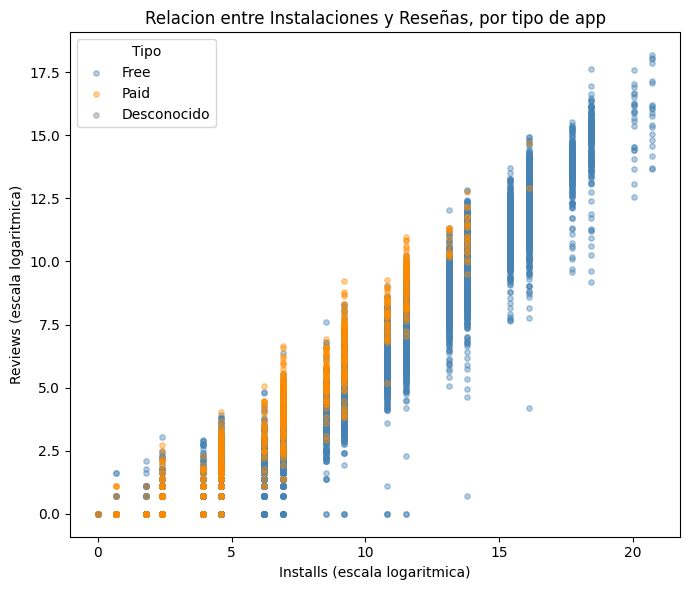

In [26]:
fig, ax = plt.subplots(figsize=(7,6))
colores = {'Free': 'steelblue', 'Paid': 'darkorange', 'Desconocido': 'gray'}
for tipo, color in colores.items():
    subset = df_clean[df_clean['Type'] == tipo]
    ax.scatter(subset['Installs_log'], subset['Reviews_log'], alpha=0.4, s=15, label=tipo, color=color)

ax.set_xlabel('Installs (escala logaritmica)')
ax.set_ylabel('Reviews (escala logaritmica)')
ax.set_title('Relacion entre Instalaciones y Reseñas, por tipo de app')
ax.legend(title='Tipo')
plt.tight_layout()
plt.show()

**Lectura del grafico:** se ve una linea de tendencia clara hacia arriba a la derecha: a mas instalaciones, mas reseñas (confirma la correlacion de 0.63 del Modulo 2). Las apps gratuitas (azul) dominan todo el rango, incluyendo los valores mas altos; las apps pagas (naranja) se concentran mas abajo a la izquierda -> confirman que **el pago es una barrera fuerte para el volumen de instalaciones**, aunque no para la calidad percibida.

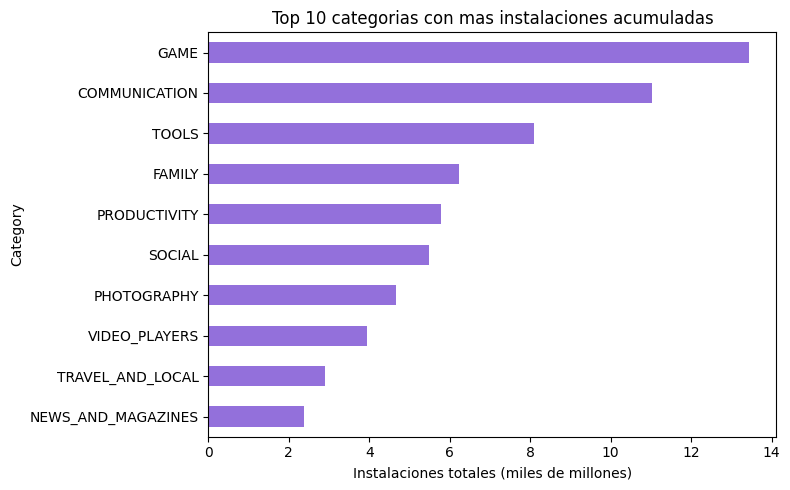

In [27]:
total_installs_categoria = df_clean.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
(total_installs_categoria / 1e9).plot(kind='barh', color='mediumpurple')
plt.xlabel('Instalaciones totales (miles de millones)')
plt.title('Top 10 categorias con mas instalaciones acumuladas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Lectura del grafico:** GAME, COMMUNICATION y PRODUCTIVITY concentran la mayor cantidad de instalaciones acumuladas del catalogo. Esto es distinto a "cuantas apps hay" (donde FAMILY ganaba) — aqui vemos **en que categorias el usuario realmente pasa/instala mas**, informacion clave si se quisiera decidir en que categoria lanzar un producto nuevo.

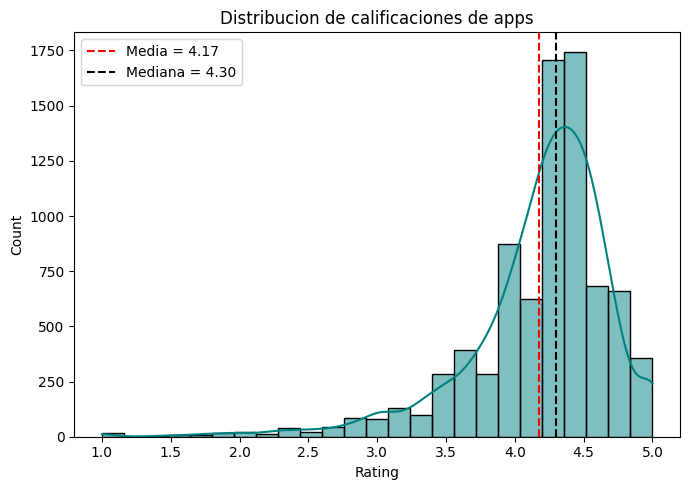

In [28]:
plt.figure(figsize=(7,5))
sns.histplot(df_clean['Rating'].dropna(), bins=25, kde=True, color='teal')
plt.axvline(df_clean['Rating'].mean(), color='red', linestyle='--', label=f"Media = {df_clean['Rating'].mean():.2f}")
plt.axvline(df_clean['Rating'].median(), color='black', linestyle='--', label=f"Mediana = {df_clean['Rating'].median():.2f}")
plt.xlabel('Rating')
plt.title('Distribucion de calificaciones de apps')
plt.legend()
plt.tight_layout()
plt.show()

**Lectura del grafico:** la distribucion esta sesgada a la izquierda (cola larga hacia ratings bajos) y concentrada entre 4.0 y 4.5. La mayoria de apps que sobreviven en la tienda son percibidas como "buenas"; muy pocas tienen rating por debajo de 3.0.

## 2. Storytelling: la historia detras de los datos

Uniendo los hallazgos de las tres fases del proyecto, la historia que cuentan los datos de Google Play Store es la siguiente:

> **El mercado de aplicaciones es profundamente desigual, pero la calidad no depende de ese tamaño.** Al explorar el dataset (Fase 1) encontramos que un cuarto de las apps estaban duplicadas o mal registradas, lo cual ya anticipaba que los datos de un mercado real vienen "sucios" y hay que depurarlos antes de confiar en ellos. Al analizar estadisticamente los datos limpios (Fase 2), confirmamos que un grupo muy pequeño de aplicaciones (Facebook, WhatsApp, Instagram) concentra una cantidad de instalaciones y reseñas miles de veces mayor que el resto del catalogo — la mediana de instalaciones (100,000) es diminuta comparada con la media (7.8 millones). Sin embargo, al revisar las correlaciones, encontramos algo contraintuitivo: **el Rating de una app casi no se relaciona con su tamaño, su precio o su popularidad**. Ni ser grande, ni ser pagada, ni ser instalada por millones garantiza mejor calificacion. Esto se confirmo en la Fase 3 al intentar predecir el Rating con un modelo de regresion lineal: el modelo solo explico el 8.8% de la variacion del Rating (R2 = 0.088), es decir, **estas variables casi no sirven para predecir que tan bien calificada estara una app** — la calidad percibida depende de factores que este dataset no captura (experiencia de usuario, estabilidad, soporte, competencia dentro de su categoria).

## 3. Modelo predictivo simple: regresion lineal para estimar el Rating

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Usamos las filas donde Rating y Size no son nulos
datos_modelo = df_clean.dropna(subset=['Rating', 'Size']).copy()

features = ['Reviews_log', 'Installs_log', 'Size', 'Price']
X = datos_modelo[features]
y = datos_modelo['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

print('Filas de entrenamiento:', len(X_train), '| Filas de prueba:', len(X_test))
print()
print('R2 (que tan bien explica el modelo la variacion del Rating):', round(r2_score(y_test, pred), 3))
print('MAE (error promedio en puntos de Rating):', round(mean_absolute_error(y_test, pred), 3))
print('RMSE:', round(mean_squared_error(y_test, pred) ** 0.5, 3))

Filas de entrenamiento: 5620 | Filas de prueba: 1406

R2 (que tan bien explica el modelo la variacion del Rating): 0.088
MAE (error promedio en puntos de Rating): 0.372
RMSE: 0.542


In [30]:
coeficientes = pd.DataFrame({'variable': features, 'coeficiente': modelo.coef_})
coeficientes

,variable,coeficiente
0,Reviews_log,0.168529
1,Installs_log,-0.149097
2,Size,-0.000287
3,Price,-0.001016


**Que hace el modelo:** una regresion lineal busca la mejor combinacion de pesos (coeficientes) para estimar el `Rating` a partir de `Reviews`, `Installs`, `Size` y `Price` (las dos primeras en escala logaritmica, como se explico en la seccion de outliers). La formula que aprendio es, en esencia:

`Rating estimado = 4.62 + 0.17 x Reviews_log - 0.15 x Installs_log - 0.0003 x Size - 0.001 x Price`

**Como se evaluo:** se separo el dataset en 80% para entrenar el modelo y 20% para probarlo con datos que nunca vio (esto evita hacer trampa evaluando con los mismos datos de entrenamiento).

**Que resultados dio (interpretacion honesta, no exagerada):**
- **R2 = 0.088** -> el modelo solo logra explicar el **8.8%** de por que varian los ratings entre apps. Es un modelo **debil**.
- **MAE = 0.37** -> en promedio, la prediccion del modelo se equivoca en poco mas de un tercio de punto (ej. predice 4.1 cuando el rating real es 4.5).
- Los coeficientes son pequeños y hasta contradictorios en signo (mas Reviews sube un poco el rating estimado, pero mas Installs lo baja un poco) -> confirma que **no hay una relacion lineal fuerte y clara** entre estas variables y el Rating.

**Conclusion del modelo:** no es que el modelo este mal construido, es que **estas variables simplemente no contienen suficiente informacion para predecir la calidad percibida de una app**. Este es en si mismo un hallazgo valioso: le dice a cualquier equipo de producto que **no puede asumir que una app grande, cara o popular sera mejor calificada** — haria falta informacion que este dataset no tiene (reseñas de texto, tasa de crashes, tiempo de respuesta a soporte, etc.) para predecir el rating de forma confiable.

## 4. Aplicacion profesional concreta

**Contexto:** como estudiante de Ingenieria de Sistemas, este tipo de analisis es directamente aplicable si en el futuro trabajo en un equipo de **desarrollo o producto de software** (una fintech, una empresa que publica apps propias, o un area de datos/BI dentro de cualquier compañia con presencia movil).

**Como lo aplicaria en un entorno laboral real:**

1. **Antes de lanzar o mejorar una app**, replicaria este pipeline (limpieza -> estadistica -> visualizacion -> modelo) sobre datos de la competencia en mi categoria especifica, para entender el rating promedio esperado, el tamaño tipico aceptado por los usuarios, y si el precio realmente afecta la adopcion en ese nicho.
2. **Para decidir estrategia de precios**, usaria el hallazgo de que Price no se correlaciona con Rating ni con Installs para argumentar, con datos, que subir o bajar el precio de una app no automaticamente mejora ni empeora su percepcion — hay que testear con datos propios, no asumir.
3. **Como ingeniero, no solo como analista**, este ejercicio refuerza una leccion clave para cualquier sistema que consuma datos externos (APIs, scraping, bases de datos de terceros): **nunca confiar en los datos crudos**. La fila corrupta, los duplicados y las inconsistencias logicas (Reviews > Installs) que encontramos son el mismo tipo de problema que hay que anticipar al diseñar un pipeline de datos en produccion (validaciones, tests de calidad de datos, alertas automaticas).
4. **Para reportar a un equipo no tecnico** (ej. gerencia de producto), usaria las visualizaciones simples (barras, histogramas) en vez de las tablas de coeficientes, porque comunican el mismo hallazgo de forma mucho mas accesible.